# Potencial Gravitacional en un Disco Protoplanetario
Estudiante: Juan Diego Rodríguez \
Profesor: José Iván Campos Rozo \
**Observatorio Astronómico Nacional, Semestre 2026-1**

Este cuaderno resuelve numéricamente la ecuación de Poisson para el potencial gravitacional de un disco protoplanetario en coordenadas cilíndricas. Se implementan y comparan los métodos iterativos de Gauss-Seidel y Sobrerrelajación Sucesiva (SOR).

### 1. Discretización de la Ecuación de Poisson

La ecuación de Poisson en coordenadas cilíndricas (asumiendo simetría azimutal, por lo que las derivadas respecto a $\theta$ son cero) está dada por:

$$ \frac{\partial^2 \Phi}{\partial r^2} + \frac{1}{r} \frac{\partial \Phi}{\partial r} + \frac{\partial^2 \Phi}{\partial z^2} = 4\pi G \rho(r, z) $$

Para una malla uniforme de tamaño $N_r \times N_z$, definimos los pasos espaciales $\Delta r = R_{\text{max}} / (N_r - 1)$ y $\Delta z = Z_{\text{max}} / (N_z - 1)$. Usando diferencias finitas centradas de segundo orden, las derivadas se aproximan como:

*   $\frac{\partial^2 \Phi}{\partial r^2} \approx \frac{\Phi_{i+1, j} - 2\Phi_{i, j} + \Phi_{i-1, j}}{\Delta r^2}$
*   $\frac{\partial \Phi}{\partial r} \approx \frac{\Phi_{i+1, j} - \Phi_{i-1, j}}{2\Delta r}$
*   $\frac{\partial^2 \Phi}{\partial z^2} \approx \frac{\Phi_{i, j+1} - 2\Phi_{i, j} + \Phi_{i, j-1}}{\Delta z^2}$

Sustituyendo estas aproximaciones en la ecuación original y despejando el término central $\Phi_{i, j}$, obtenemos la ecuación discretizada:

$$ \Phi_{i,j} = \frac{ \left( \frac{1}{\Delta r^2} + \frac{1}{2 r_i \Delta r} \right) \Phi_{i+1,j} + \left( \frac{1}{\Delta r^2} - \frac{1}{2 r_i \Delta r} \right) \Phi_{i-1,j} + \frac{1}{\Delta z^2} (\Phi_{i,j+1} + \Phi_{i,j-1}) - 4\pi G \rho_{i,j} }{ 2 \left( \frac{1}{\Delta r^2} + \frac{1}{\Delta z^2} \right) } $$

Esta expresión nos permite iterar sobre los nodos internos de la malla para encontrar la solución.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Parámetros físicos y computacionales
# ==========================================
# Unidades CGS
UA = 1.496e13         # 1 Unidad Astronómica en cm
G = 6.674e-8          # Constante de gravitación en cm^3 g^-1 s^-2

# Parámetros del disco
R_max = 10.0 * UA
Z_max = 2.0 * UA
r_0 = 3.0 * UA
h = 0.5 * UA
rho_0 = 1e-9          # g cm^-3

# Parámetros de la malla
Nr = 50
Nz = 20
dr = R_max / (Nr - 1)
dz = Z_max / (Nz - 1)

# Vectores espaciales
r = np.linspace(0, R_max, Nr)
z = np.linspace(0, Z_max, Nz)
R, Z = np.meshgrid(r, z, indexing='ij')

# Tolerancia y relajación
tol = 1e-3  # 0.1% de error relativo
omega = 1.5 # Factor SOR (lambda)

# ==========================================
# Inicialización de la densidad (rho)
# ==========================================
# Para r=0 la densidad está bien definida. 
# Evitamos división por cero en la ecuación al iterar desde i=1.
rho = rho_0 * np.exp(-R / r_0) * np.exp(-Z**2 / (2 * h**2))

### 2. Implementación de los Métodos Gauss-Seidel y SOR

Implementaremos ambas rutinas. Dado que las condiciones de frontera de Dirichlet dictan que $\Phi = 0$ en todos los bordes ($r=0$, $r=R_{\text{max}}$, $z=0$, $z=Z_{\text{max}}$), iteraremos exclusivamente sobre los nodos internos ($1 \leq i \leq N_r-2$ y $1 \leq j \leq N_z-2$).

In [2]:
def resolver_poisson(metodo='SOR', omega=1.0, max_iter=20000):
    # Matriz del potencial inicializada en 0 (cumple Dirichlet en bordes)
    Phi = np.zeros((Nr, Nz))
    
    # Pre-cálculo de coeficientes para optimizar el bucle
    alpha = 1.0 / dr**2
    beta = 1.0 / dz**2
    denominador = 2.0 * (alpha + beta)
    
    iteracion = 0
    error_max = 1.0
    
    while error_max > tol and iteracion < max_iter:
        error_max = 0.0
        Phi_old = np.copy(Phi)
        
        for i in range(1, Nr - 1):
            gamma = 1.0 / (2.0 * r[i] * dr)
            
            for j in range(1, Nz - 1):
                # Ecuación en diferencias finitas
                termino_r = (alpha + gamma) * Phi[i+1, j] + (alpha - gamma) * Phi[i-1, j]
                termino_z = beta * (Phi[i, j+1] + Phi[i, j-1])
                termino_fuente = 4 * np.pi * G * rho[i, j]
                
                # Valor Gauss-Seidel
                Phi_gs = (termino_r + termino_z - termino_fuente) / denominador
                
                # Actualización SOR
                nuevo_Phi = (1 - omega) * Phi_old[i, j] + omega * Phi_gs
                
                # Cálculo del error relativo máximo localmente
                if abs(nuevo_Phi) > 0:
                    err = abs((nuevo_Phi - Phi_old[i, j]) / nuevo_Phi)
                    if err > error_max:
                        error_max = err
                
                Phi[i, j] = nuevo_Phi
                
        iteracion += 1
        
    return Phi, iteracion

# Ejecución de los métodos
Phi_GS, iter_GS = resolver_poisson(metodo='GS', omega=1.0)
Phi_SOR, iter_SOR = resolver_poisson(metodo='SOR', omega=1.5)

print(f"Iteraciones Gauss-Seidel: {iter_GS}")
print(f"Iteraciones SOR (\u03BB=1.5): {iter_SOR}")

Iteraciones Gauss-Seidel: 162
Iteraciones SOR (λ=1.5): 65


### 3. Visualización: Mapa de Color y Curvas Equipotenciales

Graficaremos un mapa de color del potencial $\Phi(r,z)$ superponiendo curvas equipotenciales que nos ayudarán a entender la estructura topológica del campo escalar.

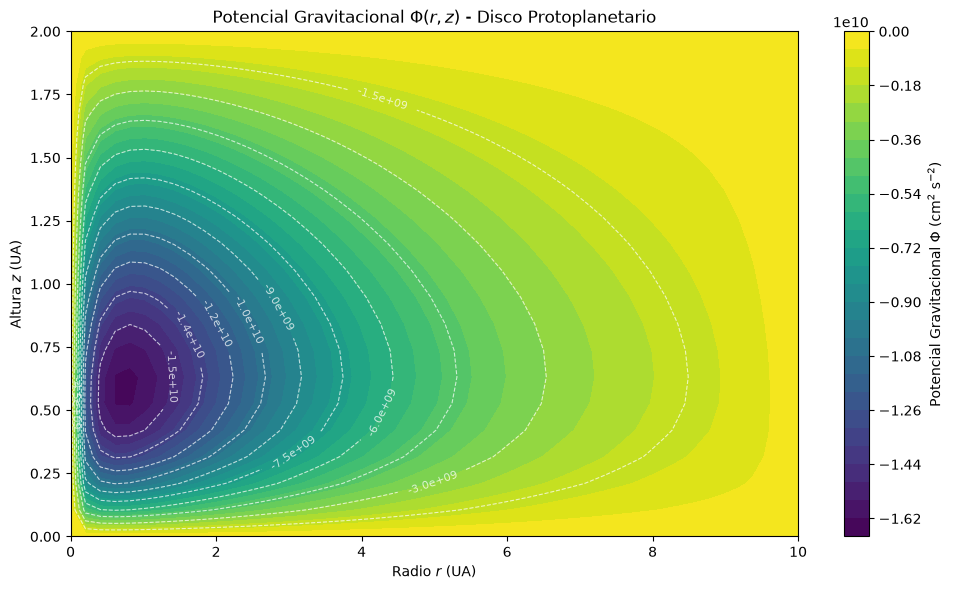

In [3]:
plt.figure(figsize=(10, 6))
# Convertimos de nuevo a UA para los ejes
r_ua = R / UA
z_ua = Z / UA

# Mapa de color
cp = plt.contourf(r_ua, z_ua, Phi_SOR, levels=30, cmap='viridis')
cbar = plt.colorbar(cp)
cbar.set_label(r'Potencial Gravitacional $\Phi$ (cm$^2$ s$^{-2}$)')

# Curvas equipotenciales
cs = plt.contour(r_ua, z_ua, Phi_SOR, levels=10, colors='white', linewidths=0.8, alpha=0.7)
plt.clabel(cs, inline=True, fontsize=8, fmt='%.1e')

plt.title(r'Potencial Gravitacional $\Phi(r,z)$ - Disco Protoplanetario')
plt.xlabel(r'Radio $r$ (UA)')
plt.ylabel(r'Altura $z$ (UA)')
plt.tight_layout()
plt.show()

### 4. Cálculo de la Fuerza Gravitacional Radial

La fuerza gravitacional (aceleración por unidad de masa) en la dirección radial está dada por el gradiente negativo del potencial:

$$F_r = -\frac{\partial \Phi}{\partial r}$$

Discretizamos esta derivada utilizando diferencias finitas centradas sobre los resultados obtenidos.

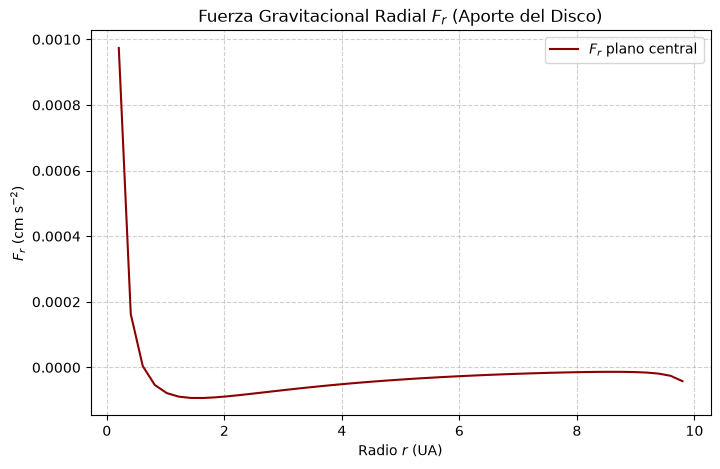

In [4]:
Fr = np.zeros((Nr, Nz))

# Derivada central para los puntos internos
for i in range(1, Nr - 1):
    for j in range(0, Nz):
        Fr[i, j] = -(Phi_SOR[i+1, j] - Phi_SOR[i-1, j]) / (2 * dr)

# Gráfico del perfil de fuerza radial en el plano medio (z cerca de h=0, usaremos el índice j=1 dado que el borde es 0 artificialmente)
idx_z_mid = 1 

plt.figure(figsize=(8, 5))
plt.plot(r[1:-1] / UA, Fr[1:-1, idx_z_mid], label=r'$F_r$ plano central', color='darkred')
plt.title(r'Fuerza Gravitacional Radial $F_r$ (Aporte del Disco)')
plt.xlabel(r'Radio $r$ (UA)')
plt.ylabel(r'$F_r$ (cm s$^{-2}$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

#### Discusión sobre la consistencia con un perfil Kepleriano

En un **disco Kepleriano ideal**, la dinámica orbital está dominada abrumadoramente por la masa de la estrella central, lo que genera una fuerza radial que decae proporcionalmente a $1/r^2$. 

El resultado numérico aquí graficado corresponde **únicamente a la auto-gravedad del disco**, dictada por la función de densidad $\rho(r, z)$. Como no incluimos un término de masa central puntual en la ecuación de Poisson (o en las condiciones de frontera en el origen), este perfil de fuerza difiere cualitativamente de un disco puramente Kepleriano. Este componente auto-gravitante presentará un comportamiento dominado por la distribución exponencial de la densidad, que tiende a ser más suave en el interior y decae más rápido en el exterior en comparación con el perfil de $1/r^2$ de una masa puntual.

### 5. Comparación con Solución Analítica de Masa Puntual

Para una masa puntual en el origen, el potencial es esféricamente simétrico:

$$ \Phi_{\text{punto}}(r,z) = -\frac{GM}{\sqrt{r^2 + z^2}} $$

*   **Comportamiento en el Origen:** El potencial de masa puntual diverge fuertemente (asíntota hacia $-\infty$) cuando $r, z \rightarrow 0$. Por el contrario, el modelo computacional de disco arroja un potencial finito y bien comportado en el centro, debido a que la masa está distribuida uniformemente (la condición artificial de Dirichlet $\Phi = 0$ obliga adicionalmente a no divergir en los límites).
*   **Geometría Equipotencial:** Para una masa puntual, las superficies equipotenciales son esferas perfectas ($\sqrt{r^2+z^2} = \text{cte}$). En contraste, las gráficas generadas demuestran que las equipotenciales del disco son elipsoides o estructuras fuertemente aplanadas a lo largo del eje $r$. Esto refleja la dependencia explícita de la función escalar de la altura $z$, determinada por el exponente gaussiano de escala vertical estelar térmica $\exp(-z^2/2h^2)$.